In [8]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

import ok_netCDF as onc

In [9]:

year=2026
month=6
day=8
hour=23

dataVolume="/Volumes/staff-umbrella/PARSAX Vadatech SkyTorque Data/"
#tarFile="2026/2026-06/2026-06-08/level2/archive_2026-06-08T02"
dataDir=f"{year}/{year}-{month:02d}/{year}-{month:02d}-{day:02d}/level2/"
tarFile=f"archive_{year}-{month:02d}-{day:02d}T{hour:02d}.tar"

strDataSrc=f"{dataVolume}{dataDir}{tarFile}"
print(f"Combining netCDF files from tar file: {strDataSrc}")

combined_ds = onc.combine_nc_from_tar(strDataSrc);


Combining netCDF files from tar file: /Volumes/staff-umbrella/PARSAX Vadatech SkyTorque Data/2026/2026-06/2026-06-08/level2/archive_2026-06-08T23.tar
Detected 6 overlapping member time ranges in /Volumes/staff-umbrella/PARSAX Vadatech SkyTorque Data/2026/2026-06/2026-06-08/level2/archive_2026-06-08T23.tar:
  Overlap between ./level2_PARSAX_2026-06-08T23-00-00Z.nc [2026-06-08T23:00:00.000000000 - 2026-06-08T23:04:59.255985000] and ./level2_PARSAX_2026-06-08T23-04-59Z.nc [2026-06-08T23:04:59.000000000 - 2026-06-08T23:09:58.739009000]
  Overlap between ./level2_PARSAX_2026-06-08T23-10-00Z.nc [2026-06-08T23:10:00.000000000 - 2026-06-08T23:14:59.266605000] and ./level2_PARSAX_2026-06-08T23-14-59Z.nc [2026-06-08T23:14:59.000000000 - 2026-06-08T23:19:58.747694999]
  Overlap between ./level2_PARSAX_2026-06-08T23-20-00Z.nc [2026-06-08T23:20:00.000000000 - 2026-06-08T23:24:59.257217999] and ./level2_PARSAX_2026-06-08T23-24-59Z.nc [2026-06-08T23:24:59.000000000 - 2026-06-08T23:29:58.747265999]
  

In [10]:
with xr.set_options(display_max_rows=200, display_width=400):
    print(combined_ds)

<xarray.Dataset> Size: 8GB
Dimensions:                            (sweep: 1, time: 7468, range: 3000, altitude: 1, latitude: 1, longitude: 1)
Coordinates:
  * time                               (time) datetime64[ns] 60kB 2026-06-08T23:00:00 2026-06-08T23:00:00.510170999 2026-06-08T23:00:01.049437999 2026-06-08T23:00:01.585851 2026-06-08T23:00:02.095571999 2026-06-08T23:00:02.606085 ... 2026-06-09T00:04:56.163804 2026-06-09T00:04:56.700097 2026-06-09T00:04:57.209342 2026-06-09T00:04:57.720865 2026-06-09T00:04:58.232009 2026-06-09T00:04:58.769517
    azimuth                            (time) float32 30kB 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 ... 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1 80.1
    elevation                          (time) float

In [11]:
'''
fig, ax = plt.subplots(figsize=(10, 6))
combined_ds["time"].plot(ax=ax)
ax.set_title("Time")
plt.show()
'''

'\nfig, ax = plt.subplots(figsize=(10, 6))\ncombined_ds["time"].plot(ax=ax)\nax.set_title("Time")\nplt.show()\n'

In [12]:
times = combined_ds['time'].values
import numpy as np
print("sorted?", np.all(np.diff(times) > np.timedelta64(0, 's')))

sorted? True


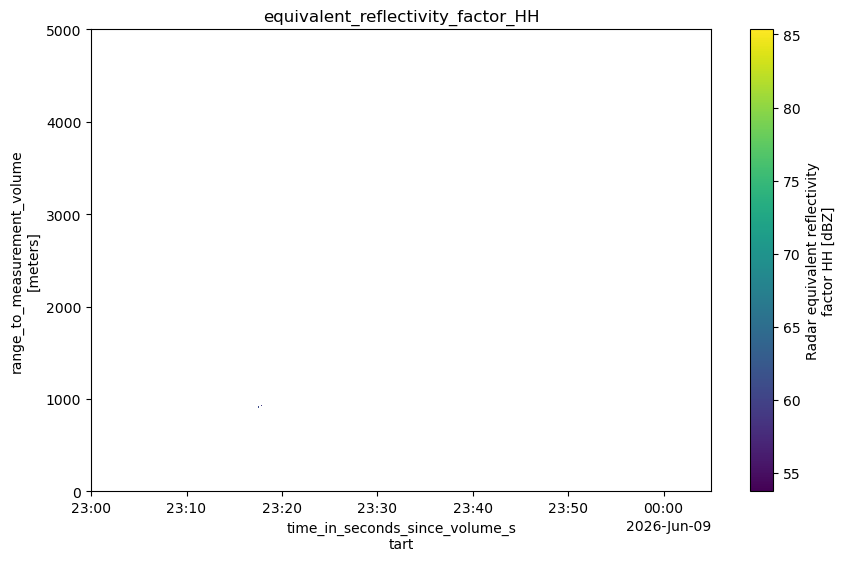

In [16]:
var_name='equivalent_reflectivity_factor_HH' #'rawreflectivity_HH' # 'ncp_HH'

fig, ax = plt.subplots(figsize=(10, 6))
combined_ds[var_name].T.plot(ax=ax, cmap="viridis")
ax.set_ylim(0, 5000)  # set vertical axis range
ax.set_title(var_name)
plt.show()

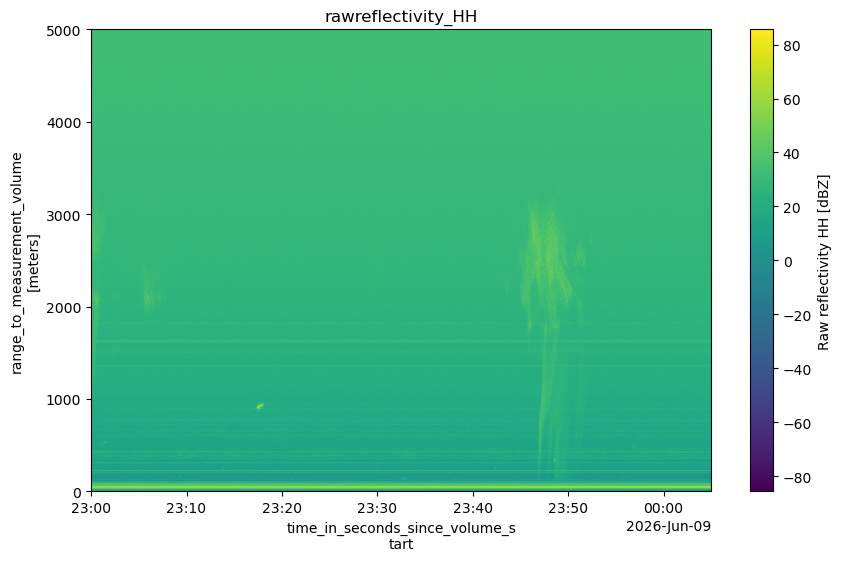

In [17]:
var_name='rawreflectivity_HH' # 'ncp_HH'

fig, ax = plt.subplots(figsize=(10, 6))
combined_ds[var_name].T.plot(ax=ax, cmap="viridis")
ax.set_ylim(0, 5000)  # set vertical axis range
ax.set_title(var_name)
plt.show()